# Estimating Time to Payment for Receivables

# Data Prep and Exploratory Data Analysis for Assets dataset

The given iput for modelling of payment behavior in CrediPay is a parquet file comprising 1001023 invoices (identified by the combination of asset_id + invoice_id) of 681 sellers from the platform. It seems that deliquency has increased in later cohorts.

My goal here aims to estabilish an analytical strategy to understand customer payment behavior on origination of new credit lines and predict time to payment for new customers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from lifelines import KaplanMeierFitter

In [2]:
assets = pd.read_parquet("../data/df_assets.parquet", engine="pyarrow")

In [3]:
unique_sellers = assets["seller_tax_id"].nunique()
print("Unique buyer_tax_id count:", unique_sellers)

Unique buyer_tax_id count: 681


In [4]:
assets.head()

,asset_id,invoice_id,face_value,buyer_tax_id,seller_tax_id,maturity_date,due_date,settled_at,created_at,reference_date
0,5c764ad8-59dc-e30a-9d73-b051582605fb,9c3673c7cbbddde1,534.41,40199547791118,60259422305974,2025-04-10,2025-04-10,2025-04-06,2025-03-13,2025-04-15
1,b947a6c4-6e17-a418-091d-c04952f85047,23ba3b2f6e5570da,165.14,40519406990678,00925347588806,2024-12-24,2024-12-24,2024-12-22,2024-12-03,2025-03-19
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,c2d4b28ddd0da663,432.55,38842652921056,14133781557079,2024-02-02,2024-02-02,2024-02-01,2024-01-26,2025-03-20
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,2e6921011ecf24f1,102.60,54929917112999,14133781557079,2023-03-08,2023-03-08,2023-03-07,2023-02-28,2025-03-20
4,3ee1a83eb0ba837d,f32ba85be54f4160,6739.70,51211364716527,87924474238085,2024-08-08,2024-08-08,2024-08-06,2024-06-24,2025-02-03


In [5]:
assets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001023 entries, 0 to 1001022
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   asset_id        1001023 non-null  object        
 1   invoice_id      1001023 non-null  object        
 2   face_value      1001023 non-null  float64       
 3   buyer_tax_id    1001023 non-null  object        
 4   seller_tax_id   1001023 non-null  object        
 5   maturity_date   1001023 non-null  object        
 6   due_date        1001023 non-null  object        
 7   settled_at      888504 non-null   datetime64[ns]
 8   created_at      997487 non-null   datetime64[ns]
 9   reference_date  1001023 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 76.4+ MB


As seen above, some of the date fields are not in proper  date format.
 
Below, all necessary columns are transformed in proper datetime fields

In [6]:
assets["maturity_date"] = pd.to_datetime(assets["maturity_date"])
assets["due_date"] = pd.to_datetime(assets["due_date"])
assets["reference_date"] = pd.to_datetime(assets["reference_date"])

---

A small fraction of the dataset (3536 records) do not contain a valid "created_at" field. 

For puprposes of modeling, these rows will not be include in the dataset as they are noninformative and will not allow obtaining a duration for the payment under analysis

In [7]:
assets_no_creation_date = assets.loc[assets.created_at.isnull()]
assets_no_creation_date.head()

,asset_id,invoice_id,face_value,buyer_tax_id,seller_tax_id,maturity_date,due_date,settled_at,created_at,reference_date
192,8b14856e-81d4-12d1-121e-dd184d44624d,38e430ce823410ca,508.36,81594288290338,16790620976050,2024-09-24,2024-09-24,2024-09-23,NaT,2024-10-18
446,28791c85-7c19-26b2-2afe-a7d761ff6ee4,c331aadd0d787702,265.77,76273056899998,16790620976050,2024-10-03,2024-10-03,2024-10-01,NaT,2024-10-18
513,2792164e-1418-b756-ecc3-f375bee75fd1,3bbe999935b85fc4,95.20,79175872783030,16790620976050,2024-09-21,2024-09-21,2024-09-21,NaT,2024-10-18
722,4363d0ec-b9f9-04a3-eb5a-f22b81320fcf,dff2a443bf446a52,488.68,91850482823519,16790620976050,2024-11-02,2024-11-02,NaT,NaT,2024-10-18
1028,2e73ce93-8a42-dc2a-f20a-ba5074c6149e,0647b22621ac40e3,403.97,16207289689363,16790620976050,2024-08-09,2024-08-09,2024-08-06,NaT,2024-10-18


In [8]:
assets_no_creation_date.asset_id.shape[0]

3536

In [9]:
assets = assets.loc[~assets.created_at.isnull()]

---

Also, more inconsistencies were found regarding payments settled before invoice creation, which were also dropped out (17069 entries)

In [10]:
assets_settled_before_creation = assets.loc[assets["settled_at"] < assets["created_at"]]
assets_settled_before_creation.head()

,asset_id,invoice_id,face_value,buyer_tax_id,seller_tax_id,maturity_date,due_date,settled_at,created_at,reference_date
15,e37f4d5d2311e287,9971a944f489f4c0,8730.85,88798121823961,20783772356477,2023-04-08,2023-04-08,2023-04-08,2023-05-05,2023-09-30
27,395facb5-6072-2424-274a-c7b6ab45e552,d4b576b61ce90faa,1821.19,04576048260798,32000772773675,2023-11-06,2023-11-06,2023-10-29,2023-10-30,2024-10-29
59,0a1c7e9c-f3b5-3e1e-4bee-76d22f77d0d4,d114da10f37b8784,4172.89,67027787761419,32000772773675,2024-05-15,2024-05-15,2024-05-13,2024-05-15,2024-11-14
94,185fea56-712d-5511-2227-26137d39ddf1,daf47c443d5a67a1,194.52,97657227874112,14133781557079,2024-02-26,2024-02-26,2024-02-18,2024-02-19,2025-03-20
114,84182548819097,6f5c8d0e991076a1,930000.00,20561897417779,66270349769454,2024-08-10,2024-08-10,2024-07-10,2024-07-11,2025-02-07


In [11]:
assets_settled_before_creation.shape

(17069, 10)

In [12]:
assets = assets.loc[~(assets["settled_at"] < assets["created_at"])]

---

And finally, some entries had a reference date maeked before the creation_date of the asset. These records (240) were also removed 

In [13]:
assets_reference_before_creation = assets.loc[
    assets["created_at"] > assets["reference_date"]
]
assets_reference_before_creation

,asset_id,invoice_id,face_value,buyer_tax_id,seller_tax_id,maturity_date,due_date,settled_at,created_at,reference_date
5424,04d10c1b73674b54,26ea0eef8fe61cd0,8625.92,03600041347396,13469743835956,2024-03-22,2024-03-22,2024-03-20,2024-03-07,2024-03-01
5610,3b4d06587800ad41,5dc5fc13d304ba59,724.50,51552550140006,38537894264356,2024-04-10,2024-04-10,NaT,2024-03-13,2024-03-01
9072,d7ee0faf516f7992,f8b0667c203a20b0,869.22,54114595343284,38537894264356,2024-04-01,2024-04-01,NaT,2024-03-04,2024-03-01
11459,c1b01d7bc1a7541b,31c9386fc098561b,575.28,85379969249379,38537894264356,2024-03-25,2024-03-25,2024-03-24,2024-03-11,2024-03-01
28307,2c17e1359f9b7a9a,3d2588fbb49dc240,1685.83,31541615783075,13469743835956,2024-04-06,2024-04-06,NaT,2024-03-14,2024-03-01
...,...,...,...,...,...,...,...,...,...,...
990262,63a7c74c762d30d4,ec25c9357133f549,290.00,32837879248448,13469743835956,2024-03-16,2024-03-16,2024-03-16,2024-03-06,2024-03-01
992308,e22d84f5eec26831,4942f0dd70354ea6,233.56,34395982710629,38537894264356,2024-03-19,2024-03-19,2024-03-17,2024-03-05,2024-03-01
994923,d8395c41d4337d07,371e630740d4edc6,877.64,05090459899160,13469743835956,2024-04-15,2024-04-15,NaT,2024-03-15,2024-03-01
996131,d5d58e7743fc1681,c9bcd777d428ed12,703.90,28812305311817,13469743835956,2024-03-20,2024-03-20,2024-03-19,2024-03-04,2024-03-01


In [14]:
assets_reference_before_creation.shape

(240, 10)

In [15]:
assets = assets.loc[~(assets["created_at"] > assets["reference_date"])]

---

With the assets dataset cleansed, we move on to exploratory analysis on assets payment data for CrediPay.

In [16]:
assets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980178 entries, 0 to 1001022
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   asset_id        980178 non-null  object        
 1   invoice_id      980178 non-null  object        
 2   face_value      980178 non-null  float64       
 3   buyer_tax_id    980178 non-null  object        
 4   seller_tax_id   980178 non-null  object        
 5   maturity_date   980178 non-null  datetime64[ns]
 6   due_date        980178 non-null  datetime64[ns]
 7   settled_at      868146 non-null  datetime64[ns]
 8   created_at      980178 non-null  datetime64[ns]
 9   reference_date  980178 non-null  datetime64[ns]
dtypes: datetime64[ns](5), float64(1), object(4)
memory usage: 82.3+ MB


Making some sanity checks in cleaned assets table!

In [17]:
assert assets["created_at"].notnull().all(), "There are missing values in 'created_at'"
assert (assets["settled_at"] > assets["created_at"]).any(), (
    "'settled_at' is greater than 'created_at' in some rows"
)
assert (assets["created_at"] < assets["reference_date"]).any(), (
    "'created_at' is greater than 'reference_date' in some rows"
)

With all setup, Time to move on to Duration table setup

duration_days is calculated based on time difference in days of "settled at" or ("reference date", for unpaid invoices) and "created_at"

"paid" is a flag for the event of interest

"late_payment" is a flag for payments made after due date. It is not strictly necessary for model construction, but will be used for exploratory purposes only.

In [18]:
duration_table = assets[
    [
        "asset_id",
        "seller_tax_id",
        "face_value",
        "created_at",
        "settled_at",
        "due_date",
        "reference_date",
    ]
]

duration_table["duration_days"] = np.where(
    duration_table["settled_at"].isnull(),
    (duration_table["reference_date"] - duration_table["created_at"]).dt.days,
    (duration_table["settled_at"] - duration_table["created_at"]).dt.days,
)

duration_table["paid"] = np.where(duration_table["settled_at"].isnull(), 0, 1)

duration_table["late_payment"] = np.where(
    (duration_table["paid"] == 1)
    & (duration_table["settled_at"] > duration_table["due_date"]),
    1,
    0,
)

In [19]:
duration_table.head(10)

,asset_id,seller_tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment
0,5c764ad8-59dc-e30a-9d73-b051582605fb,60259422305974,534.41,2025-03-13,2025-04-06,2025-04-10,2025-04-15,24.0,1,0
1,b947a6c4-6e17-a418-091d-c04952f85047,00925347588806,165.14,2024-12-03,2024-12-22,2024-12-24,2025-03-19,19.0,1,0
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,14133781557079,432.55,2024-01-26,2024-02-01,2024-02-02,2025-03-20,6.0,1,0
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,14133781557079,102.60,2023-02-28,2023-03-07,2023-03-08,2025-03-20,7.0,1,0
4,3ee1a83eb0ba837d,87924474238085,6739.70,2024-06-24,2024-08-06,2024-08-08,2025-02-03,43.0,1,0
5,34ff0791-cf60-abe9-61fc-128af36e80fb,79510873311545,93000.00,2024-02-22,2024-04-24,2024-04-26,2024-10-01,62.0,1,0
6,d0c86ee5-cbfd-fc62-aaa0-6a4c282e4668,32000772773675,1988.80,2024-04-29,2024-09-01,2024-07-29,2024-11-19,125.0,1,1
7,bc45ac40-9219-9255-1f25-fd143cfd7a19,14133781557079,124.48,2023-08-31,2023-10-04,2023-09-08,2025-03-20,34.0,1,1
8,047388a0-5328-e748-da58-ecc8e31fbb5a,60259422305974,527.90,2025-03-27,NaT,2025-05-08,2025-04-15,19.0,0,0
9,544e1cc7-b1c9-0426-0e01-a518f469fba7,14133781557079,115.15,2023-03-08,2023-03-19,2023-03-19,2025-03-20,11.0,1,0


making a further sanity check for duration table! (null values indicate data quality issues on input)

In [20]:
assert (duration_table.duration_days > 0).any(), (
    "Negative durations are not allowed. Check your input data!"
)

For exploratory data analysis and further modeling, some additional columns for year and quarter of credit origination are also set up.

In [21]:
duration_table["cohort"] = duration_table["created_at"].dt.to_period("M")
duration_table["cohort_year"] = duration_table["created_at"].dt.to_period("Y")

As we are using this duration table for further analysis and model development, it will be persisted in the "/data/output" path}

In [22]:
duration_table.to_parquet("../data/output/assets_duration_table.parquet")

Finally we modularize the creation of duration_table in the cell below. All these functions are saved in the **'../case/helper_functions.py'** file of this folder

In [23]:
def create_duration_table(assets: pd.DataFrame):
    """
    Create duration table from assets table given

    Parameters: asset (a dataframe cointaining columns used for creation of a duration table aimed for time to payment analysis.
     In this function this field are needed in the input dataframe
     ['asset_id', 'seller_tax_id', 'face_value' ,'created_at', 'settled_at' ,'due_date',  'reference_date'] )
     It returns a duration table ready for use for survival analysis and modeling

    """

    assets["maturity_date"] = pd.to_datetime(assets["maturity_date"])
    assets["due_date"] = pd.to_datetime(assets["due_date"])
    assets["reference_date"] = pd.to_datetime(assets["reference_date"])

    assets = assets.loc[~assets.created_at.isnull()]
    assets = assets.loc[~(assets["settled_at"] < assets["created_at"])]
    assets = assets.loc[~(assets["created_at"] > assets["reference_date"])]

    duration_table = assets[
        [
            "asset_id",
            "seller_tax_id",
            "face_value",
            "created_at",
            "settled_at",
            "due_date",
            "reference_date",
        ]
    ]

    duration_table["duration_days"] = np.where(
        duration_table["settled_at"].isnull(),
        (duration_table["reference_date"] - duration_table["created_at"]).dt.days,
        (duration_table["settled_at"] - duration_table["created_at"]).dt.days,
    )

    duration_table["paid"] = np.where(duration_table["settled_at"].isnull(), 0, 1)

    duration_table["late_payment"] = np.where(
        (duration_table["paid"] == 1)
        & (duration_table["settled_at"] > duration_table["due_date"]),
        1,
        0,
    )

    duration_table["cohort"] = duration_table["created_at"].dt.to_period("M")
    duration_table["cohort_year"] = duration_table["created_at"].dt.to_period("Y")

    return duration_table

In [24]:
duration_table = create_duration_table(assets)
duration_table.head()

,asset_id,seller_tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment,cohort,cohort_year
0,5c764ad8-59dc-e30a-9d73-b051582605fb,60259422305974,534.41,2025-03-13,2025-04-06,2025-04-10,2025-04-15,24.0,1,0,2025-03,2025
1,b947a6c4-6e17-a418-091d-c04952f85047,00925347588806,165.14,2024-12-03,2024-12-22,2024-12-24,2025-03-19,19.0,1,0,2024-12,2024
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,14133781557079,432.55,2024-01-26,2024-02-01,2024-02-02,2025-03-20,6.0,1,0,2024-01,2024
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,14133781557079,102.60,2023-02-28,2023-03-07,2023-03-08,2025-03-20,7.0,1,0,2023-02,2023
4,3ee1a83eb0ba837d,87924474238085,6739.70,2024-06-24,2024-08-06,2024-08-08,2025-02-03,43.0,1,0,2024-06,2024


---

Below it is simplied some summary statistics for the duration table focusing on payment status of the given asset. We see that in a historical sense, the public under study has a deliquency rate of about 11% of total assets generated. 
Also important to note, 20% of seller base has experienced deliquency in the past

,paid,n_assets,n_sellers,total_face_value,mean_face_value,mean_duration,median_duration,std_duration,prop
0,0,112032,137,1.085554e+08,968.968164,73.088332,29.0,128.970139,0.114298
1,1,868146,624,1.120053e+09,1290.166778,39.013995,34.0,34.903315,0.885702


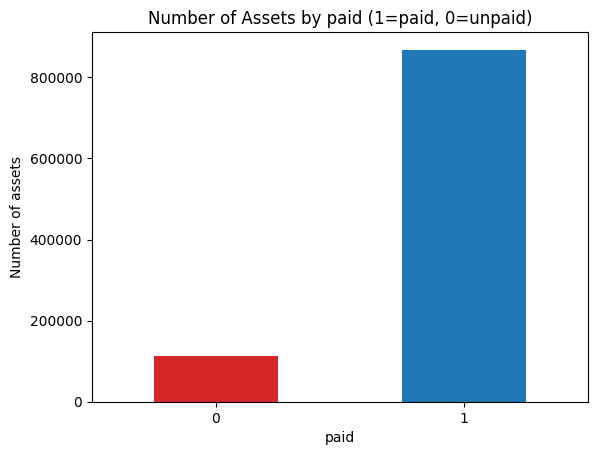

In [25]:
# Group by 'paid' and compute summary statistics
grouped_paid = (
    duration_table.groupby("paid")
    .agg(
        n_assets=("asset_id", "count"),
        n_sellers=("seller_tax_id", "nunique"),
        total_face_value=("face_value", "sum"),
        mean_face_value=("face_value", "mean"),
        mean_duration=("duration_days", "mean"),
        median_duration=("duration_days", "median"),
        std_duration=("duration_days", "std"),
    )
    .reset_index()
)

# proportion of total assets
grouped_paid["prop"] = grouped_paid["n_assets"] / grouped_paid["n_assets"].sum()

display(grouped_paid)

# Simple bar plot of counts by paid status
grouped_paid.set_index("paid")["n_assets"].plot(
    kind="bar",
    title="Number of Assets by paid (1=paid, 0=unpaid)",
    color=["#d62728" if p == 0 else "#1f77b4" for p in grouped_paid["paid"]],
)
plt.xlabel("paid")
plt.ylabel("Number of assets")
plt.xticks(rotation=0)
plt.show()

In 2023, with a huge increase in company client base, there was a slight increase in deliquency rate along the years, and a clear problem in recent cohorts (2024 to 2025). Previois to 2023, the amount of transactions made is negligible compared to  2023 onwards

In [26]:
# Analysis of unpaid (paid == 0) by cohort (quarter)
# Uses existing `duration_table` in the notebook.

cohort_summary = (
    duration_table.groupby("cohort")
    .apply(
        lambda g: pd.Series(
            {
                "total": len(g),
                "unpaid_count": (g["paid"] == 0).sum(),
                "unpaid_rate": (g["paid"] == 0).mean(),
                "unpaid_median_duration": g.loc[
                    g["paid"] == 0, "duration_days"
                ].median(),
                "unpaid_mean_duration": g.loc[g["paid"] == 0, "duration_days"].mean(),
                "n_sellers": g["seller_tax_id"].nunique(),
                "n_sellers_with_unpaid": g.loc[
                    g["paid"] == 0, "seller_tax_id"
                ].nunique(),
            }
        )
    )
    .sort_index()
)

# Convert index to string for clearer printing/plotting
cohort_summary.index = cohort_summary.index.astype(str)

# Print chronological cohort summary
cohort_summary

,total,unpaid_count,unpaid_rate,unpaid_median_duration,unpaid_mean_duration,n_sellers,n_sellers_with_unpaid
cohort,,,,,,,
2021-07,5.0,0.0,0.000000,NaN,NaN,1.0,0.0
2021-08,3.0,0.0,0.000000,NaN,NaN,1.0,0.0
2021-09,2.0,0.0,0.000000,NaN,NaN,1.0,0.0
2021-10,14.0,0.0,0.000000,NaN,NaN,1.0,0.0
2021-11,25.0,0.0,0.000000,NaN,NaN,1.0,0.0
2021-12,24.0,0.0,0.000000,NaN,NaN,1.0,0.0
2022-01,13.0,0.0,0.000000,NaN,NaN,3.0,0.0
2022-02,8.0,0.0,0.000000,NaN,NaN,2.0,0.0
2022-03,20.0,0.0,0.000000,NaN,NaN,3.0,0.0


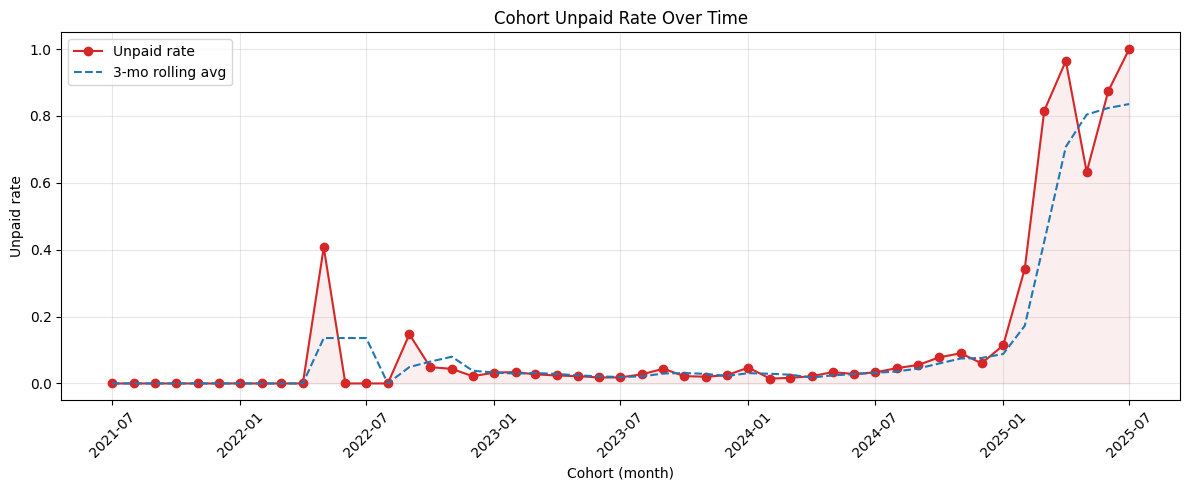

In [27]:
cs = cohort_summary.copy()
cs["cohort_start"] = pd.to_datetime(cs.index, format="%Y-%m")
cs = cs.sort_values("cohort_start").set_index("cohort_start")

cs["paid_count"] = cs["total"] - cs["unpaid_count"]
cs["unpaid_rate_roll3"] = cs["unpaid_rate"].rolling(window=3, min_periods=1).mean()

# 1) Line chart: unpaid rate with 3-month rolling average
plt.figure(figsize=(12, 5))
plt.plot(cs.index, cs["unpaid_rate"], marker="o", label="Unpaid rate", color="#d62728")
plt.plot(
    cs.index,
    cs["unpaid_rate_roll3"],
    linestyle="--",
    label="3-mo rolling avg",
    color="#1f77b4",
)
plt.fill_between(cs.index, cs["unpaid_rate"], alpha=0.08, color="#d62728")
plt.title("Cohort Unpaid Rate Over Time")
plt.xlabel("Cohort (month)")
plt.ylabel("Unpaid rate")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In order to understand the behavior of payment of our seller cohorts, a Kaplan Meier estimate based on generated duration table is set up. It will be further used for exploration in the context of company and bureau data.

In [28]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=duration_table["duration_days"], event_observed=duration_table["paid"]
)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 980178 total observations, 112032 right-censored observations>

In [29]:
survival_table = kmf.survival_function_
survival_table.head(10)

,KM_estimate
timeline,
0.0,0.995966
1.0,0.991203
2.0,0.984836
3.0,0.976539
4.0,0.961945
5.0,0.924325
6.0,0.873471
7.0,0.827382
8.0,0.809913


We see that payment flow in the early days seems to be ok. As we move for medium and long runs (after ~100 days) the risk profile of the portfolio seems to quickly degradate. At a first sight, it seems that there 3 behaviors

* Sellers who pay quickly (0 up to 60 days)
* Sellers who need special attention regarding credit policies (60-100 days)
* Sellers with chronic cash flow (from 100 days and beyond)

The behavior of the curve after this elbow at about 100 days line, indicates that the risk profile kept constant in a low rate of future payment.

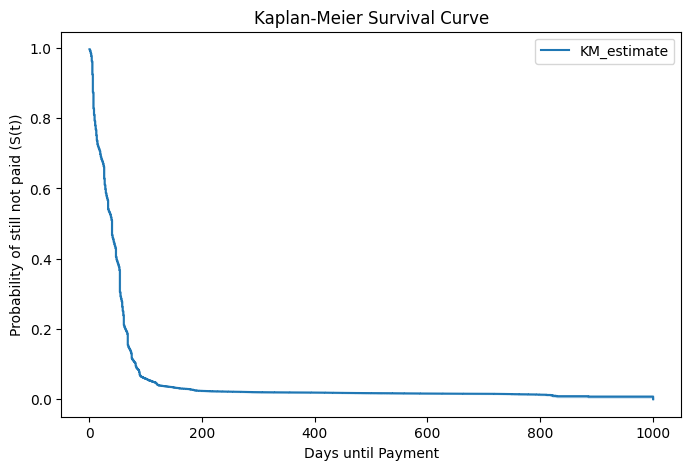

In [30]:
plt.figure(figsize=(8, 5))
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Days until Payment")
plt.ylabel("Probability of still not paid (S(t))")
plt.show()

In [31]:
duration_table.groupby(["cohort_year", "paid"])["face_value"].sum().reset_index()

,cohort_year,paid,face_value
0,2021,1,2.655818e+05
1,2022,0,6.801495e+04
2,2022,1,6.990010e+06
3,2023,0,4.910770e+06
4,2023,1,2.336071e+08
5,2024,0,6.028439e+07
6,2024,1,8.189315e+08
7,2025,0,4.329226e+07
8,2025,1,6.025889e+07


Analyzing the behavior of yearly cohorts, we see a couple of different patterns. In the first year, 2021, we see a very steady profile for payment, with only a small fraction of defaulters after 2 years. In 2022, it was also shown to be a controlled year. As the portfolio increased, in 2023, the risk profile changed considerably as 2024. It is necessary an action to change this behavior and improve the percent of payments in each cohort.

the function below is used throught other notebooks to make comparative plots of Kaplan-Meier plots and giving it proper labels

In [32]:
def plot_km_curve_category(col, df):
    """
    Plot Kaplan-Meier survival curves for each category in the specified column.

    Parameters:
    - col: str, column name to group by
    - df: DataFrame, data to use (default: assets_duration_company)
    """
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(12, 7))
    labels = []
    for cat, grp in df.groupby(col):
        kmf.fit(
            grp["duration_days"],
            event_observed=grp["paid"],
            label=f"{cat} (n={len(grp)})",
        )
        kmf.plot(ci_show=False)
        labels.append(cat)
    plt.title(f"Kaplan–Meier: Time to Payment by {col}")
    plt.xlabel("Duration (days)")
    plt.ylabel("Survival probability (not yet paid)")
    plt.legend()
    plt.grid(True)
    plt.show()
    return labels

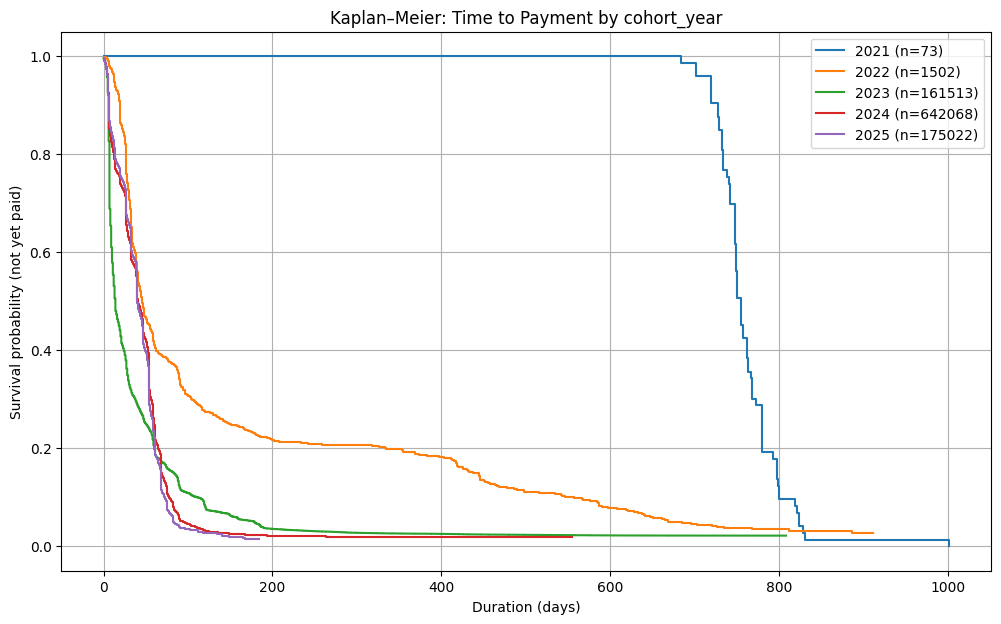

[Period('2021', 'Y-DEC'),
 Period('2022', 'Y-DEC'),
 Period('2023', 'Y-DEC'),
 Period('2024', 'Y-DEC'),
 Period('2025', 'Y-DEC')]

In [33]:
plot_km_curve_category("cohort_year", df=duration_table)

Testing the  Kaplan-Meier fit, segmenting good payers and payers who delay (put are not censored), it can be seen more clearly the pattern of a steady curve after 100 days needed for payment. The late payers group has a significantly lower tendency to pay as time goes by 

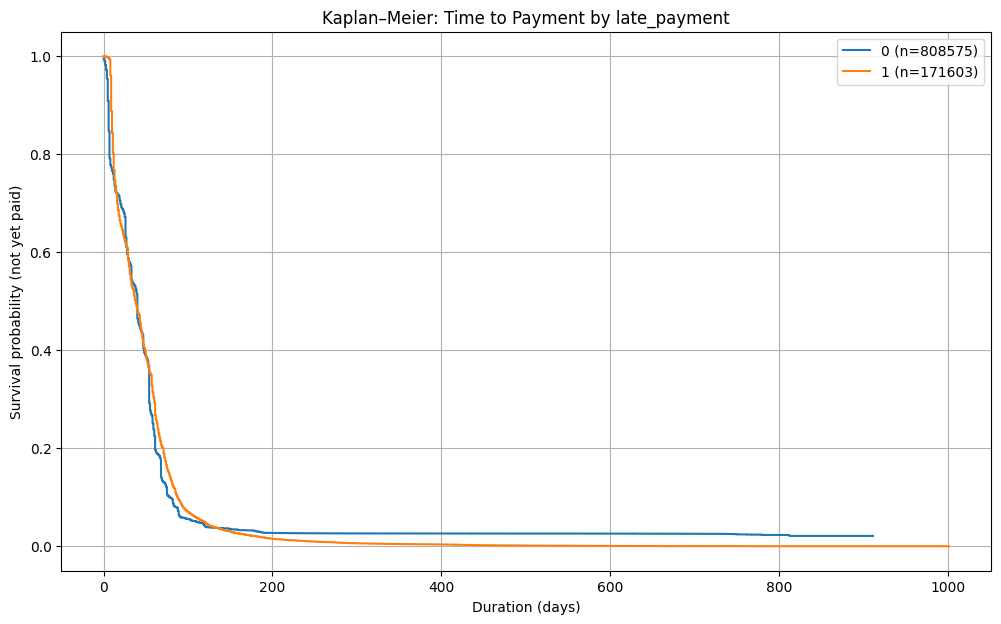

[0, 1]

In [34]:
plot_km_curve_category("late_payment", duration_table)

---